In [1]:
import os
import json
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
folder_list = [name for name in os.listdir() if (name.startswith("PCA") or name.startswith("NMF"))]
folder_list

['NMF_Swimmer_3000_025_denoise_info_test',
 'NMF_Swimmer_3000_025_denoise_info',
 'PCA_UTK_1500_015_denoise_info',
 'PCA_UTK_1500_025_denoise_info',
 'NMF_Swimmer_3000_015_denoise_info_test',
 'PCA_UTK_3000_015_denoise_info',
 'PCA_Olivetti_3000_025_denoise_info',
 'NMF_Olivetti_3000_015_denoise_info_test',
 'PCA_Olivetti_3000_015_denoise_info',
 'PCA_UTK_3000_025_denoise_info',
 'PCA_Swimmer_3000_015_denoise_info',
 'PCA_Swimmer_3000_025_denoise_info',
 'NMF_Olivetti_3000_015_denoise_info_test.xlsx',
 'NMF_Olivetti_3000_025_denoise_info',
 'NMF_Swimmer_3000_015_denoise_info_test.xlsx']

In [3]:
def get_table(folder_name):
    info_list = list()
    for file_name in os.listdir(folder_name):
        file_path = os.path.join(folder_name, file_name)

        with open(file_path, "r") as f:
            info = json.load(f)

        info_list.append(info)
    data = pd.DataFrame(info_list).sort_values("rank").reset_index(drop=True)
    return data

In [4]:
def get_stats(df, num):
    mask_r1 = (df["delta_positive_num"] == num).values
    mask = (df["delta_positive_num"] > num - 2).values
    
    if mask_r1.any():
        first_pos = np.argmax(mask_r1)
        R1 = df["rank"].iloc[first_pos].item()
    
        after = mask[first_pos:]
        last_pos = first_pos + np.argmin(after)
        # last_pos = first_pos + np.flatnonzero(after)[-1]
        R2 = df["rank"].iloc[last_pos].item()
    else:
        R1 = None
        R2 = None

    delta_idx = df["delta_mean"].idxmax()
    rank_delta_max = df.loc[delta_idx, "rank"].item()
    delta_mean_max = df.loc[delta_idx, "delta_mean"].item()

    acc_idx = df["denoised_top1"].idxmax()
    rank_acc_max = df.loc[acc_idx, "rank"].item()
    acc_max = df.loc[acc_idx, "denoised_top1"].item()
    
    return R1, R2, rank_delta_max, delta_mean_max, rank_acc_max, acc_max, df["rank"].min().item(), df["rank"].max().item()

In [5]:
# df_nmf_swimmer_25 = get_table("NMF_Swimmer_3000_015_denoise_info")
# df_nmf_swimmer_25.iloc[:30]

In [6]:
# get_stats(df_nmf_swimmer_25, 256)

In [7]:
df_nmf_swimmer_15 = get_table("NMF_Swimmer_3000_015_denoise_info_test")
df_nmf_swimmer_25 = get_table("NMF_Swimmer_3000_025_denoise_info")
df_pca_swimmer_15 = get_table("PCA_Swimmer_3000_015_denoise_info")
df_pca_swimmer_25 = get_table("PCA_Swimmer_3000_025_denoise_info")

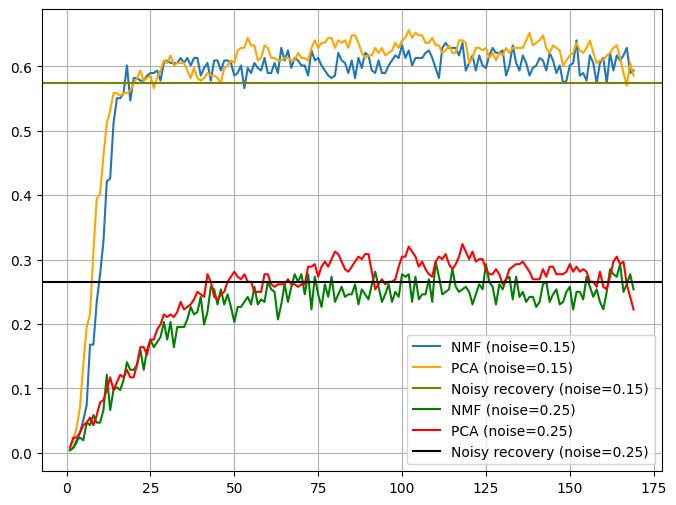

In [8]:
plt.figure(figsize=(8, 6))
plt.plot(df_nmf_swimmer_15["rank"].iloc[:169], df_nmf_swimmer_15["denoised_top1"].iloc[:169], label="NMF (noise=0.15)")
plt.plot(df_pca_swimmer_15["rank"].iloc[:169], df_pca_swimmer_15["denoised_top1"].iloc[:169], color="orange", label="PCA (noise=0.15)")
plt.axhline(df_nmf_swimmer_15["noisy_top1"].iloc[0], color="olive", label="Noisy recovery (noise=0.15)")

plt.plot(df_nmf_swimmer_25["rank"].iloc[:169], df_nmf_swimmer_25["denoised_top1"].iloc[:169], color="green", label="NMF (noise=0.25)")
plt.plot(df_pca_swimmer_25["rank"].iloc[:169], df_pca_swimmer_25["denoised_top1"].iloc[:169], color="red", label="PCA (noise=0.25)")
plt.axhline(df_nmf_swimmer_25["noisy_top1"].iloc[0], color="black", label="Noisy recovery (noise=0.25)")

plt.grid()
plt.legend()

plt.show()

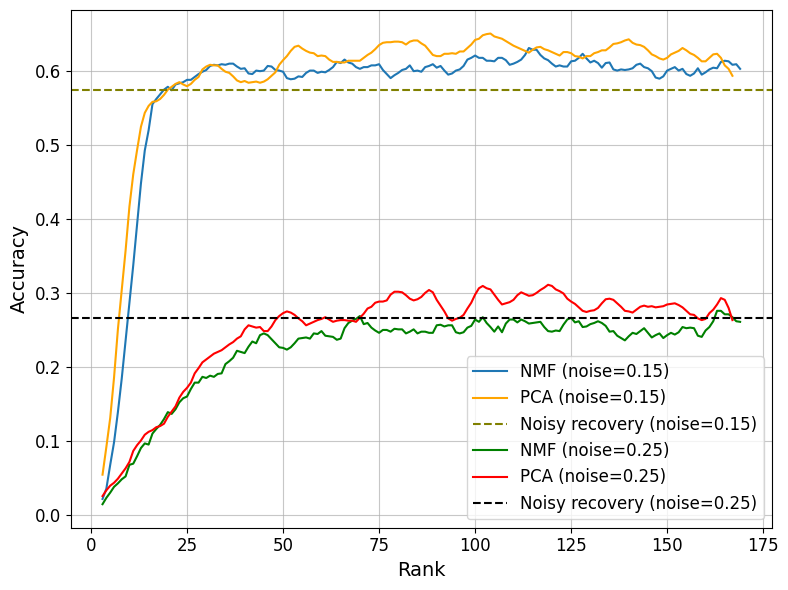

In [9]:
window = 5

df_nmf_swimmer_15["denoised_top1_smooth"] = (
    df_nmf_swimmer_15["denoised_top1"].rolling(window=window, center=True).mean()
)
df_pca_swimmer_15["denoised_top1_smooth"] = (
    df_pca_swimmer_15["denoised_top1"].rolling(window=window, center=True).mean()
)
df_nmf_swimmer_25["denoised_top1_smooth"] = (
    df_nmf_swimmer_25["denoised_top1"].rolling(window=window, center=True).mean()
)
df_pca_swimmer_25["denoised_top1_smooth"] = (
    df_pca_swimmer_25["denoised_top1"].rolling(window=window, center=True).mean()
)

plt.figure(figsize=(8, 6))

plt.plot(
    df_nmf_swimmer_15["rank"].iloc[:169],
    df_nmf_swimmer_15["denoised_top1_smooth"].iloc[:169],
    label="NMF (noise=0.15)",
)
plt.plot(
    df_pca_swimmer_15["rank"].iloc[:169],
    df_pca_swimmer_15["denoised_top1_smooth"].iloc[:169],
    color="orange",
    label="PCA (noise=0.15)",
)
plt.axhline(
    df_nmf_swimmer_15["noisy_top1"].iloc[0],
    color="olive",
    linestyle="--",
    label="Noisy recovery (noise=0.15)",
)

plt.plot(
    df_nmf_swimmer_25["rank"].iloc[:169],
    df_nmf_swimmer_25["denoised_top1_smooth"].iloc[:169],
    color="green",
    label="NMF (noise=0.25)",
)
plt.plot(
    df_pca_swimmer_25["rank"].iloc[:169],
    df_pca_swimmer_25["denoised_top1_smooth"].iloc[:169],
    color="red",
    label="PCA (noise=0.25)",
)
plt.axhline(
    df_nmf_swimmer_25["noisy_top1"].iloc[0],
    color="black",
    linestyle="--",
    label="Noisy recovery (noise=0.25)",
)

plt.grid(True, alpha=0.7)
plt.legend(fontsize=12)
plt.xlabel("Rank", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
# plt.title("NMF vs PCA denoising performance (smoothed, window=5)")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.savefig("nmf_pca_denoising_comparison_on_swimmer.pdf")

plt.show()

In [10]:
# def get_stats(df, num):
#     mask = (df["delta_positive_num"] > num - 2).values
    
#     if mask.any():
#         first_pos = np.argmax(mask)
#         R1 = df["rank"].iloc[first_pos].item()
    
#         after = mask[first_pos:]
#         last_pos = first_pos + np.argmin(after)
#         # last_pos = first_pos + np.flatnonzero(after)[-1]
#         R2 = df["rank"].iloc[last_pos].item()
#     else:
#         R1 = None
#         R2 = None

#     delta_idx = df["delta_mean"].idxmax()
#     rank_delta_max = df.loc[delta_idx, "rank"].item()
#     delta_mean_max = df.loc[delta_idx, "delta_mean"].item()

#     acc_idx = df["denoised_top1"].idxmax()
#     rank_acc_max = df.loc[acc_idx, "rank"].item()
#     acc_max = df.loc[acc_idx, "denoised_top1"].item()
    
#     return R1, R2, rank_delta_max, delta_mean_max, rank_acc_max, acc_max, df["rank"].min().item(), df["rank"].max().item()

In [11]:
df_nmf_olivetti_15.to_excel("NMF_Olivetti_3000_015_denoise_info_test.xlsx", index=False)

NameError: name 'df_nmf_olivetti_15' is not defined

In [12]:
df_nmf_olivetti_15 = get_table("NMF_Olivetti_3000_015_denoise_info_test") 

In [13]:
get_stats(df_nmf_olivetti_15, 400)

(12, 254, 28, 0.017335558223092074, 295, 0.9325, 1, 297)

In [14]:
df_nmf_olivetti_15

,rank,delta_mean,delta_var,delta_positive_num,denoised_top1,noisy_top1,denoised_top5,noisy_top5,denoised_top10,noisy_top10
0,1,0.003683,0.000064,290,0.0025,1.0,0.0125,1.0,0.0250,1.0
1,2,0.007524,0.000060,339,0.0075,1.0,0.0275,1.0,0.0600,1.0
2,3,0.009750,0.000055,371,0.0050,1.0,0.0475,1.0,0.1025,1.0
3,4,0.011140,0.000050,382,0.0100,1.0,0.0625,1.0,0.1325,1.0
4,5,0.012210,0.000050,390,0.0175,1.0,0.0925,1.0,0.2000,1.0
...,...,...,...,...,...,...,...,...,...,...
292,293,0.004046,0.000024,398,0.9175,1.0,0.9975,1.0,1.0000,1.0
293,294,0.004012,0.000024,398,0.9275,1.0,0.9975,1.0,1.0000,1.0
294,295,0.003961,0.000023,399,0.9325,1.0,0.9950,1.0,1.0000,1.0
295,296,0.003964,0.000023,400,0.9325,1.0,0.9950,1.0,1.0000,1.0


In [15]:
return R1, R2, rank_delta_max, delta_mean_max, rank_acc_max, acc_max, df["rank"].min().item(), df["rank"].max().item()

SyntaxError: 'return' outside function (560379035.py, line 1)

In [16]:
df_nmf_swimmer_15.to_excel("NMF_Swimmer_3000_015_denoise_info_test.xlsx", index=False)


In [17]:
get_stats(df_nmf_swimmer_15, 256)

(5, 114, 15, 0.2138820127132269, 186, 0.64453125, 1, 199)

In [18]:
df_nmf_swimmer_15.iloc[:10]

,rank,delta_mean,delta_var,delta_positive_num,denoised_top1,noisy_top1,denoised_top5,noisy_top5,denoised_top10,noisy_top10,denoised_top1_smooth
0,1,0.124320,0.003425,253,0.003906,0.574219,0.019531,0.90625,0.039062,0.957031,NaN
1,2,0.130926,0.003529,253,0.007812,0.574219,0.039062,0.90625,0.074219,0.957031,NaN
2,3,0.138717,0.003553,253,0.015625,0.574219,0.078125,0.90625,0.164062,0.957031,0.021875
3,4,0.146347,0.003435,253,0.031250,0.574219,0.148438,0.90625,0.277344,0.957031,0.035937
4,5,0.153791,0.003189,256,0.050781,0.574219,0.226562,0.90625,0.402344,0.957031,0.067969
5,6,0.159787,0.003084,256,0.074219,0.574219,0.332031,0.90625,0.503906,0.957031,0.098437
6,7,0.167028,0.003226,256,0.167969,0.574219,0.425781,0.90625,0.554688,0.957031,0.139063
7,8,0.173658,0.003233,256,0.167969,0.574219,0.488281,0.90625,0.628906,0.957031,0.184375
8,9,0.179893,0.003045,256,0.234375,0.574219,0.605469,0.90625,0.753906,0.957031,0.235156
9,10,0.186289,0.002890,256,0.277344,0.574219,0.679688,0.90625,0.812500,0.957031,0.285938


In [19]:
df_nmf_swimmer_15.iloc[110:120]

,rank,delta_mean,delta_var,delta_positive_num,denoised_top1,noisy_top1,denoised_top5,noisy_top5,denoised_top10,noisy_top10,denoised_top1_smooth
110,111,0.050907,0.000453,256,0.582031,0.574219,0.906250,0.90625,0.968750,0.957031,0.611719
111,112,0.050256,0.000413,256,0.628906,0.574219,0.890625,0.90625,0.968750,0.957031,0.614844
112,113,0.049090,0.000445,256,0.636719,0.574219,0.898438,0.90625,0.964844,0.957031,0.621094
113,114,0.047420,0.000631,253,0.628906,0.574219,0.902344,0.90625,0.980469,0.957031,0.630469
114,115,0.047517,0.000528,254,0.628906,0.574219,0.890625,0.90625,0.964844,0.957031,0.628125
115,116,0.046455,0.000452,256,0.628906,0.574219,0.902344,0.90625,0.972656,0.957031,0.628125
116,117,0.045252,0.000388,256,0.617188,0.574219,0.902344,0.90625,0.972656,0.957031,0.621094
117,118,0.044860,0.000424,255,0.636719,0.574219,0.906250,0.90625,0.968750,0.957031,0.616406
118,119,0.043403,0.000396,254,0.593750,0.574219,0.898438,0.90625,0.968750,0.957031,0.614062
119,120,0.042810,0.000427,256,0.605469,0.574219,0.902344,0.90625,0.964844,0.957031,0.609375


In [20]:
get_stats(df_nmf_swimmer_25, 256)

(8, 10, 7, 0.13834181833363063, 110, 0.296875, 1, 199)

In [21]:
df_nmf_swimmer_25.iloc[:30]

,rank,delta_mean,delta_var,delta_positive_num,denoised_top1,noisy_top1,denoised_top5,noisy_top5,denoised_top10,noisy_top10,denoised_top1_smooth
0,1,0.135561,0.003513,253,0.003906,0.265625,0.019531,0.632812,0.039062,0.792969,NaN
1,2,0.134991,0.003493,253,0.007812,0.265625,0.027344,0.632812,0.066406,0.792969,NaN
2,3,0.134936,0.003571,251,0.019531,0.265625,0.058594,0.632812,0.105469,0.792969,0.014844
3,4,0.138167,0.003569,252,0.023438,0.265625,0.078125,0.632812,0.160156,0.792969,0.023438
4,5,0.135562,0.003470,253,0.019531,0.265625,0.121094,0.632812,0.191406,0.792969,0.030469
5,6,0.135289,0.003310,252,0.046875,0.265625,0.140625,0.632812,0.281250,0.792969,0.038281
6,7,0.138342,0.003187,254,0.042969,0.265625,0.175781,0.632812,0.300781,0.792969,0.042969
7,8,0.138200,0.003044,256,0.058594,0.265625,0.222656,0.632812,0.308594,0.792969,0.048438
8,9,0.136420,0.003126,255,0.046875,0.265625,0.207031,0.632812,0.320312,0.792969,0.052344
9,10,0.133513,0.002950,254,0.046875,0.265625,0.222656,0.632812,0.359375,0.792969,0.067969


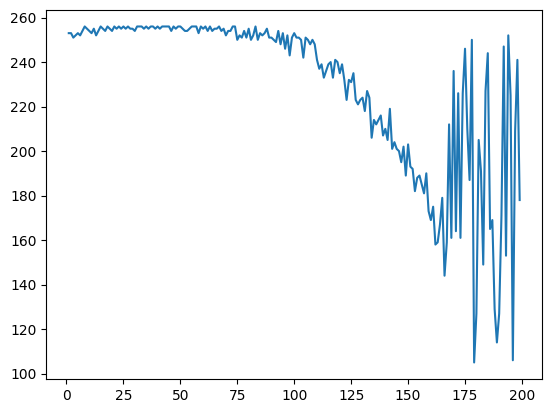

In [22]:
plt.plot(df_nmf_swimmer_25["rank"], df_nmf_swimmer_25["delta_positive_num"])
# plt.axhline(1495, color="red")
# plt.ylim(1480, 1510)

In [23]:
data_path = "../files/UTK-1500-0_15.xlsx"
df_utk1_15 = pd.read_excel(data_path)
df_utk1_15

,delta_mean,delta_var,delta_positive_num,denoised_top1,noisy_top1,denoised_top5,noisy_top5,denoised_top10,noisy_top10,rank
0,-0.007199,0.000425,450,0.000667,0.986,0.003333,0.995333,0.006667,0.997333,1
1,0.003184,0.000463,808,0.001333,0.986,0.007333,0.995333,0.015333,0.997333,2
2,0.011718,0.000400,1109,0.004000,0.986,0.018000,0.995333,0.032667,0.997333,3
3,0.015099,0.000364,1240,0.006000,0.986,0.030667,0.995333,0.050667,0.997333,4
4,0.017300,0.000356,1314,0.009333,0.986,0.040667,0.995333,0.072667,0.997333,5
...,...,...,...,...,...,...,...,...,...,...
194,0.026861,0.000185,1496,0.719333,0.986,0.881333,0.995333,0.924000,0.997333,195
195,0.026872,0.000181,1496,0.726667,0.986,0.886667,0.995333,0.924000,0.997333,196
196,0.026700,0.000173,1496,0.716667,0.986,0.884667,0.995333,0.922000,0.997333,197
197,0.026818,0.000181,1496,0.736000,0.986,0.888000,0.995333,0.923333,0.997333,198


In [24]:
get_stats(df_utk1_15, 1500)

(47, 129, 53, 0.03246670759870917, 198, 0.736, 1, 199)

In [25]:
df_utk1_15.iloc[40:55]

,delta_mean,delta_var,delta_positive_num,denoised_top1,noisy_top1,denoised_top5,noisy_top5,denoised_top10,noisy_top10,rank
40,0.032115,0.000395,1499,0.546667,0.986,0.777333,0.995333,0.848000,0.997333,41
41,0.032218,0.000398,1499,0.554667,0.986,0.784000,0.995333,0.850000,0.997333,42
42,0.032259,0.000395,1499,0.559333,0.986,0.786667,0.995333,0.858000,0.997333,43
43,0.032340,0.000396,1499,0.570667,0.986,0.800667,0.995333,0.864000,0.997333,44
44,0.032298,0.000397,1499,0.566667,0.986,0.798667,0.995333,0.861333,0.997333,45
45,0.032272,0.000392,1499,0.574000,0.986,0.801333,0.995333,0.863333,0.997333,46
46,0.032403,0.000394,1500,0.588667,0.986,0.810667,0.995333,0.876667,0.997333,47
47,0.032368,0.000390,1499,0.586667,0.986,0.813333,0.995333,0.875333,0.997333,48
48,0.032264,0.000369,1499,0.586000,0.986,0.810667,0.995333,0.881333,0.997333,49
49,0.032280,0.000369,1499,0.599333,0.986,0.821333,0.995333,0.878000,0.997333,50


In [26]:
data_path = "../files/UTK-1500-0_25.xlsx"
df_utk1_25 = pd.read_excel(data_path)
df_utk1_25

,delta_mean,delta_var,delta_positive_num,denoised_top1,noisy_top1,denoised_top5,noisy_top5,denoised_top10,noisy_top10,rank
0,0.020699,0.000372,1405,0.000667,0.46,0.003333,0.619333,0.006667,0.676,1
1,0.029055,0.000492,1478,0.001333,0.46,0.004667,0.619333,0.010000,0.676,2
2,0.036136,0.000516,1497,0.002000,0.46,0.008000,0.619333,0.016667,0.676,3
3,0.038894,0.000502,1499,0.002667,0.46,0.011333,0.619333,0.023333,0.676,4
4,0.040640,0.000506,1500,0.003333,0.46,0.012667,0.619333,0.026000,0.676,5
...,...,...,...,...,...,...,...,...,...,...
194,0.038783,0.000283,1494,0.050667,0.46,0.120000,0.619333,0.178000,0.676,195
195,0.038838,0.000283,1494,0.051333,0.46,0.121333,0.619333,0.182000,0.676,196
196,0.038766,0.000290,1494,0.052000,0.46,0.122000,0.619333,0.176667,0.676,197
197,0.038568,0.000285,1494,0.050667,0.46,0.116667,0.619333,0.180667,0.676,198


In [27]:
get_stats(df_utk1_25, 1500)

(5, 126, 24, 0.049289031234539, 188, 0.05533333333333333, 1, 199)

(1480.0, 1510.0)

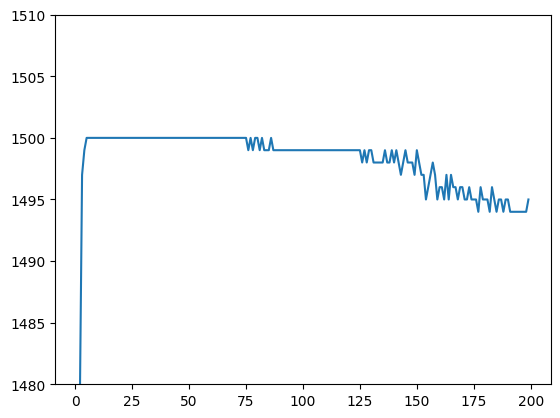

In [28]:
plt.plot(df_utk1_25["rank"], df_utk1_25["delta_positive_num"])
# plt.axhline(1495, color="red")
plt.ylim(1480, 1510)

In [29]:
df_utk1_25.iloc[115:135]

,delta_mean,delta_var,delta_positive_num,denoised_top1,noisy_top1,denoised_top5,noisy_top5,denoised_top10,noisy_top10,rank
115,0.043253,0.000320,1499,0.041333,0.46,0.110000,0.619333,0.163333,0.676,116
116,0.043177,0.000322,1499,0.040000,0.46,0.110000,0.619333,0.170667,0.676,117
117,0.043133,0.000321,1499,0.043333,0.46,0.113333,0.619333,0.170667,0.676,118
118,0.043091,0.000318,1499,0.041333,0.46,0.109333,0.619333,0.172667,0.676,119
119,0.042957,0.000310,1499,0.041333,0.46,0.109333,0.619333,0.169333,0.676,120
120,0.042930,0.000320,1499,0.043333,0.46,0.106667,0.619333,0.168000,0.676,121
121,0.042856,0.000319,1499,0.042667,0.46,0.106000,0.619333,0.167333,0.676,122
122,0.042764,0.000314,1499,0.042667,0.46,0.107333,0.619333,0.164000,0.676,123
123,0.042841,0.000310,1499,0.042000,0.46,0.111333,0.619333,0.170667,0.676,124
124,0.042743,0.000319,1499,0.044000,0.46,0.113333,0.619333,0.169333,0.676,125


In [30]:
data_path = "../files/UTK-3000-0_15.xlsx"
df_utk2_15 = pd.read_excel(data_path)
df_utk2_15

,delta_mean,delta_var,delta_positive_num,denoised_top1,noisy_top1,denoised_top5,noisy_top5,denoised_top10,noisy_top10,rank
0,-0.007117,0.000419,921,0.000333,0.978667,0.001667,0.995333,0.003333,0.996333,1
1,0.003265,0.000455,1627,0.001000,0.978667,0.004000,0.995333,0.008000,0.996333,2
2,0.012160,0.000393,2260,0.002333,0.978667,0.010333,0.995333,0.019667,0.996333,3
3,0.015381,0.000353,2524,0.004000,0.978667,0.018333,0.995333,0.034667,0.996333,4
4,0.017453,0.000341,2654,0.005000,0.978667,0.025667,0.995333,0.050000,0.996333,5
...,...,...,...,...,...,...,...,...,...,...
191,0.031335,0.000236,3000,0.793333,0.978667,0.907000,0.995333,0.937000,0.996333,192
192,0.031269,0.000235,3000,0.790000,0.978667,0.904333,0.995333,0.932667,0.996333,193
193,0.031275,0.000234,3000,0.795000,0.978667,0.906000,0.995333,0.934000,0.996333,194
194,0.031272,0.000231,2999,0.796333,0.978667,0.909333,0.995333,0.936000,0.996333,195


In [31]:
df_utk2_15.iloc[25:50]

,delta_mean,delta_var,delta_positive_num,denoised_top1,noisy_top1,denoised_top5,noisy_top5,denoised_top10,noisy_top10,rank
25,0.030783,0.000372,2995,0.266000,0.978667,0.521000,0.995333,0.617000,0.996333,26
26,0.031020,0.000377,2996,0.283333,0.978667,0.537667,0.995333,0.639333,0.996333,27
27,0.031207,0.000378,2996,0.299333,0.978667,0.558333,0.995333,0.659667,0.996333,28
28,0.031407,0.000380,2996,0.319000,0.978667,0.579000,0.995333,0.677667,0.996333,29
29,0.031581,0.000380,2996,0.337333,0.978667,0.600667,0.995333,0.694667,0.996333,30
30,0.031748,0.000382,2996,0.355333,0.978667,0.616667,0.995333,0.712000,0.996333,31
31,0.031886,0.000383,2996,0.373000,0.978667,0.636000,0.995333,0.721333,0.996333,32
32,0.032061,0.000383,2997,0.391000,0.978667,0.653333,0.995333,0.740333,0.996333,33
33,0.032184,0.000383,2997,0.408000,0.978667,0.665667,0.995333,0.754000,0.996333,34
34,0.032273,0.000382,2997,0.422000,0.978667,0.679667,0.995333,0.760333,0.996333,35


In [32]:
get_stats(df_utk2_15, 3000)

(43, 43, 73, 0.03405127042150426, 195, 0.7963333333333333, 1, 196)

In [33]:
df_utk2_15.iloc[30:70]

,delta_mean,delta_var,delta_positive_num,denoised_top1,noisy_top1,denoised_top5,noisy_top5,denoised_top10,noisy_top10,rank
30,0.031748,0.000382,2996,0.355333,0.978667,0.616667,0.995333,0.712000,0.996333,31
31,0.031886,0.000383,2996,0.373000,0.978667,0.636000,0.995333,0.721333,0.996333,32
32,0.032061,0.000383,2997,0.391000,0.978667,0.653333,0.995333,0.740333,0.996333,33
33,0.032184,0.000383,2997,0.408000,0.978667,0.665667,0.995333,0.754000,0.996333,34
34,0.032273,0.000382,2997,0.422000,0.978667,0.679667,0.995333,0.760333,0.996333,35
35,0.032396,0.000382,2997,0.435000,0.978667,0.688667,0.995333,0.775667,0.996333,36
36,0.032514,0.000384,2998,0.455333,0.978667,0.702000,0.995333,0.782333,0.996333,37
37,0.032632,0.000385,2998,0.469000,0.978667,0.712667,0.995333,0.790000,0.996333,38
38,0.032714,0.000383,2997,0.479333,0.978667,0.724000,0.995333,0.795667,0.996333,39
39,0.032809,0.000384,2998,0.500667,0.978667,0.732000,0.995333,0.802667,0.996333,40


In [34]:
data_path = "../files/UTK-3000-0_25.xlsx"
df_utk2_25 = pd.read_excel(data_path)
df_utk2_25

,delta_mean,delta_var,delta_positive_num,denoised_top1,noisy_top1,denoised_top5,noisy_top5,denoised_top10,noisy_top10,rank
0,0.020632,0.000361,2807,0.000333,0.418,0.001667,0.564333,0.003333,0.620667,1
1,0.029015,0.000479,2952,0.000667,0.418,0.002667,0.564333,0.005333,0.620667,2
2,0.036332,0.000499,2991,0.001333,0.418,0.004667,0.564333,0.009333,0.620667,3
3,0.039040,0.000485,2997,0.002000,0.418,0.007667,0.564333,0.015000,0.620667,4
4,0.040711,0.000485,3000,0.002000,0.418,0.010000,0.564333,0.017333,0.620667,5
...,...,...,...,...,...,...,...,...,...,...
182,0.045247,0.000310,2997,0.043333,0.418,0.121333,0.564333,0.180333,0.620667,183
183,0.045293,0.000312,2997,0.044333,0.418,0.122333,0.564333,0.182333,0.620667,184
184,0.045258,0.000311,2997,0.045000,0.418,0.122333,0.564333,0.183333,0.620667,185
185,0.045158,0.000309,2997,0.042333,0.418,0.120667,0.564333,0.179000,0.620667,186


In [35]:
get_stats(df_utk2_25, 3000)

(5, 156, 35, 0.05109227301891645, 185, 0.045, 1, 187)

In [36]:
df_utk2_25.iloc[150:160]

,delta_mean,delta_var,delta_positive_num,denoised_top1,noisy_top1,denoised_top5,noisy_top5,denoised_top10,noisy_top10,rank
150,0.046307,0.000335,3000,0.040667,0.418,0.118667,0.564333,0.173667,0.620667,151
151,0.046244,0.000337,3000,0.041667,0.418,0.118000,0.564333,0.173333,0.620667,152
152,0.046291,0.000334,3000,0.042333,0.418,0.119000,0.564333,0.175667,0.620667,153
153,0.046309,0.000335,2999,0.040667,0.418,0.119333,0.564333,0.178000,0.620667,154
154,0.046198,0.000333,2999,0.043000,0.418,0.115333,0.564333,0.177000,0.620667,155
155,0.046164,0.000330,2998,0.042000,0.418,0.119333,0.564333,0.174667,0.620667,156
156,0.046124,0.000332,2999,0.043000,0.418,0.117333,0.564333,0.175333,0.620667,157
157,0.046118,0.000331,2999,0.042000,0.418,0.121000,0.564333,0.179333,0.620667,158
158,0.046049,0.000329,3000,0.041333,0.418,0.117333,0.564333,0.178000,0.620667,159
159,0.046017,0.000329,2999,0.040333,0.418,0.121333,0.564333,0.177667,0.620667,160


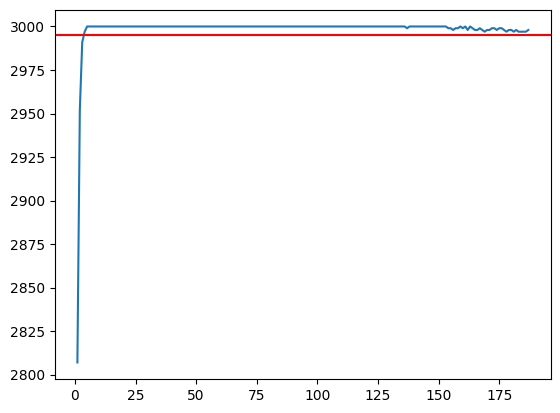

In [37]:
plt.plot(df_utk2_25["rank"], df_utk2_25["delta_positive_num"])
plt.axhline(2995, color="red")
# plt.ylim(1480, 1510)

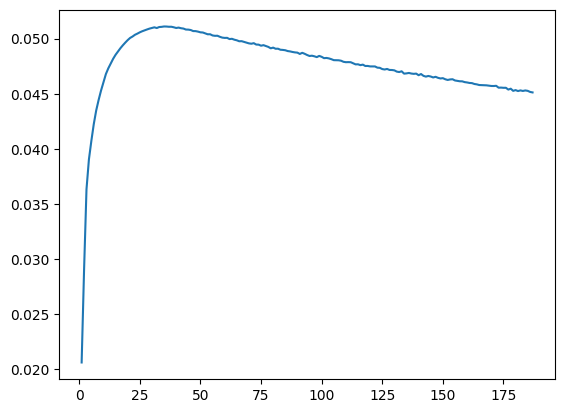

In [38]:
plt.plot(df_utk2_25["rank"], df_utk2_25["delta_mean"])

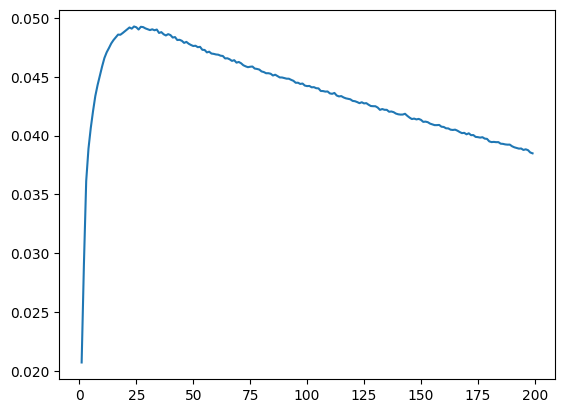

In [39]:
plt.plot(df_utk1_25["rank"], df_utk1_25["delta_mean"])

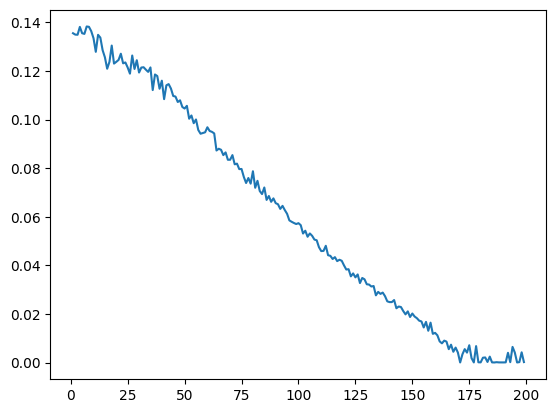

In [40]:
plt.plot(df_nmf_swimmer_25["rank"], df_nmf_swimmer_25["delta_mean"])

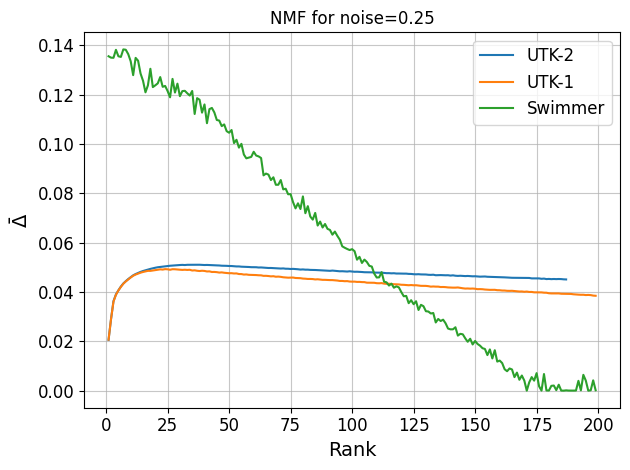

In [41]:
plt.plot(df_utk2_25["rank"], df_utk2_25["delta_mean"], label="UTK-2")
plt.plot(df_utk1_25["rank"], df_utk1_25["delta_mean"], label="UTK-1")
plt.plot(df_nmf_swimmer_25["rank"], df_nmf_swimmer_25["delta_mean"], label="Swimmer")

# plt.legend()

# plt.show()


plt.grid(True, alpha=0.7)
plt.legend(fontsize=12)
plt.xlabel("Rank", fontsize=14)
plt.ylabel(r"$\bar{\Delta}$", fontsize=14)
plt.title("NMF for noise=0.25")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.savefig("nmf_delta_mean_025_v1.pdf")

plt.show()

In [43]:
df_utk2_15

,delta_mean,delta_var,delta_positive_num,denoised_top1,noisy_top1,denoised_top5,noisy_top5,denoised_top10,noisy_top10,rank
0,-0.007117,0.000419,921,0.000333,0.978667,0.001667,0.995333,0.003333,0.996333,1
1,0.003265,0.000455,1627,0.001000,0.978667,0.004000,0.995333,0.008000,0.996333,2
2,0.012160,0.000393,2260,0.002333,0.978667,0.010333,0.995333,0.019667,0.996333,3
3,0.015381,0.000353,2524,0.004000,0.978667,0.018333,0.995333,0.034667,0.996333,4
4,0.017453,0.000341,2654,0.005000,0.978667,0.025667,0.995333,0.050000,0.996333,5
...,...,...,...,...,...,...,...,...,...,...
191,0.031335,0.000236,3000,0.793333,0.978667,0.907000,0.995333,0.937000,0.996333,192
192,0.031269,0.000235,3000,0.790000,0.978667,0.904333,0.995333,0.932667,0.996333,193
193,0.031275,0.000234,3000,0.795000,0.978667,0.906000,0.995333,0.934000,0.996333,194
194,0.031272,0.000231,2999,0.796333,0.978667,0.909333,0.995333,0.936000,0.996333,195


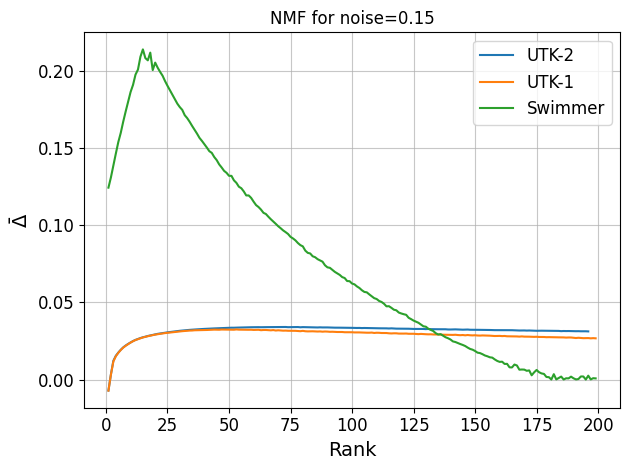

In [44]:
plt.plot(df_utk2_15["rank"], df_utk2_15["delta_mean"], label="UTK-2")
plt.plot(df_utk1_15["rank"], df_utk1_15["delta_mean"], label="UTK-1")
plt.plot(df_nmf_swimmer_15["rank"], df_nmf_swimmer_15["delta_mean"], label="Swimmer")

# plt.legend()

# plt.show()


plt.grid(True, alpha=0.7)
plt.legend(fontsize=12)
plt.xlabel("Rank", fontsize=14)
plt.ylabel(r"$\bar{\Delta}$", fontsize=14)
plt.title("NMF for noise=0.15")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.savefig("nmf_delta_mean_015_v1.pdf")

plt.show()

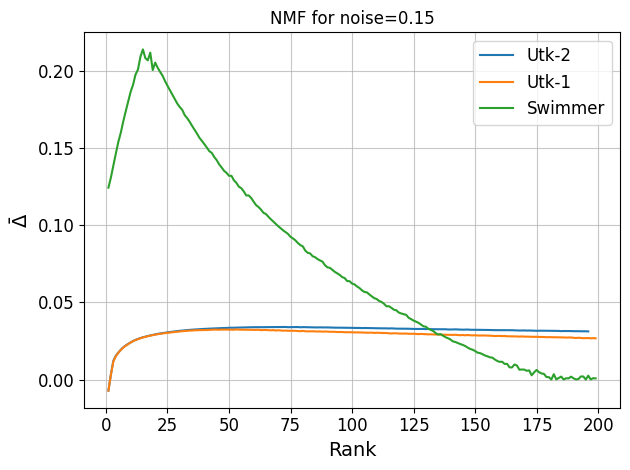

In [141]:
plt.plot(df_utk2_15["rank"], df_utk2_15["delta_mean"], label="UTK-2")
plt.plot(df_utk1_15["rank"], df_utk1_15["delta_mean"], label="UTK-1")
plt.plot(df_nmf_swimmer_15["rank"], df_nmf_swimmer_15["delta_mean"], label="Swimmer")

# plt.legend()

# plt.show()


plt.grid(True, alpha=0.7)
plt.legend(fontsize=12)
plt.xlabel("Rank", fontsize=14)
plt.ylabel(r"$\bar{\Delta}$", fontsize=14)
plt.title("NMF for noise=0.15")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.savefig("nmf_delta_mean_015_v1.pdf")

plt.show()

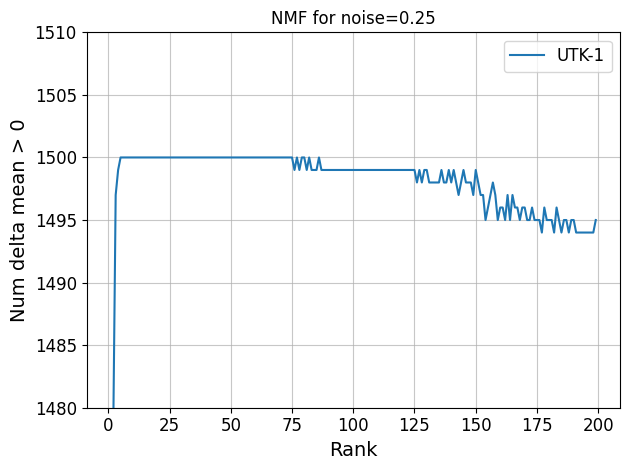

In [118]:
plt.plot(df_utk1_25["rank"], df_utk1_25["delta_positive_num"], label="UTK-1")
# plt.axhline(1495, color="red")
plt.ylim(1480, 1510)


plt.grid(True, alpha=0.7)
plt.legend(fontsize=12)
plt.xlabel("Rank", fontsize=14)
plt.ylabel("Num delta mean > 0", fontsize=14)
plt.title("NMF for noise=0.25")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.savefig("nmf_delta_mean_positiove_num_UTK1_025.pdf")

plt.show()

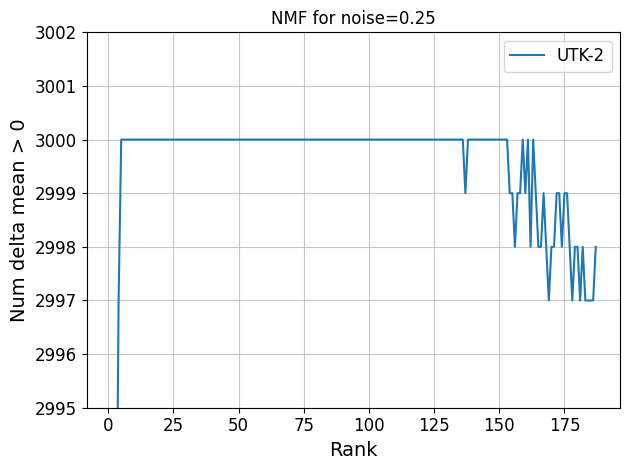

In [119]:
plt.plot(df_utk2_25["rank"], df_utk2_25["delta_positive_num"], label="UTK-2")
# plt.axhline(1495, color="red")
plt.ylim(2995, 3002)


plt.grid(True, alpha=0.7)
plt.legend(fontsize=12)
plt.xlabel("Rank", fontsize=14)
plt.ylabel("Num delta mean > 0", fontsize=14)
plt.title("NMF for noise=0.25")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.savefig("nmf_delta_mean_positiove_num_UTK2_025.pdf")

plt.show()

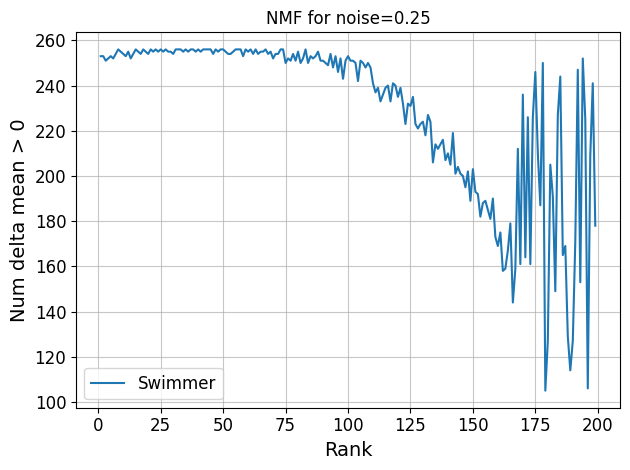

In [120]:
plt.plot(df_nmf_swimmer_25["rank"], df_nmf_swimmer_25["delta_positive_num"], label="Swimmer")
# plt.axhline(1495, color="red")
# plt.ylim(1480, 1510)


plt.grid(True, alpha=0.7)
plt.legend(fontsize=12)
plt.xlabel("Rank", fontsize=14)
plt.ylabel("Num delta mean > 0", fontsize=14)
plt.title("NMF for noise=0.25")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.savefig("nmf_delta_mean_positiove_num_swimmer_025.pdf")

plt.show()

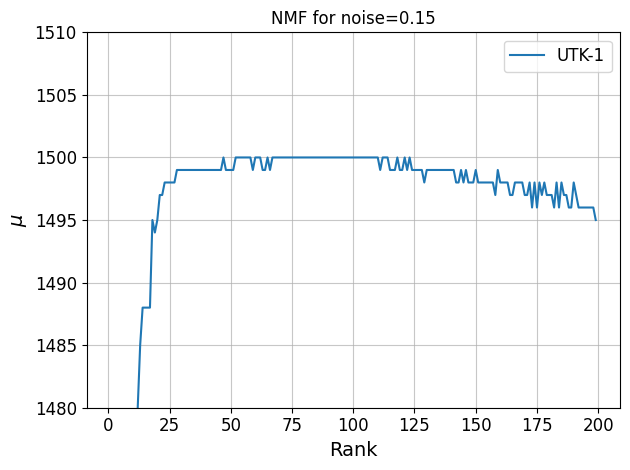

In [138]:
plt.plot(df_utk1_15["rank"], df_utk1_15["delta_positive_num"], label="UTK-1")
# plt.axhline(1495, color="red")
plt.ylim(1480, 1510)


plt.grid(True, alpha=0.7)
plt.legend(fontsize=12)
plt.xlabel("Rank", fontsize=14)
plt.ylabel(r"$\mu$", fontsize=14)
plt.title("NMF for noise=0.15")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.savefig("nmf_delta_mean_positiove_num_UTK1_015_v1.pdf")

plt.show()

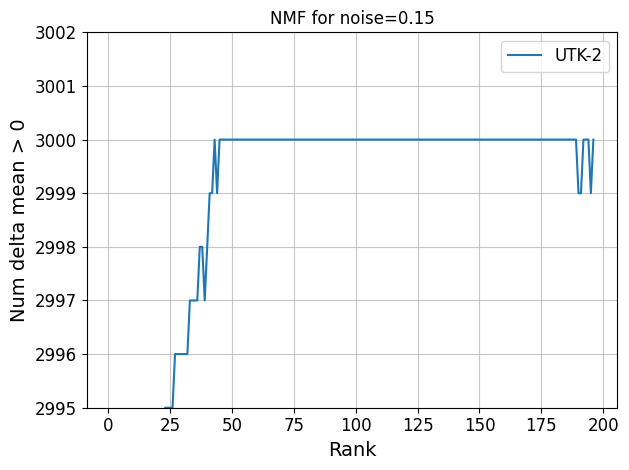

In [122]:
plt.plot(df_utk2_15["rank"], df_utk2_15["delta_positive_num"], label="UTK-2")
# plt.axhline(1495, color="red")
plt.ylim(2995, 3002)


plt.grid(True, alpha=0.7)
plt.legend(fontsize=12)
plt.xlabel("Rank", fontsize=14)
plt.ylabel("Num delta mean > 0", fontsize=14)
plt.title("NMF for noise=0.15")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.savefig("nmf_delta_mean_positiove_num_UTK2_015.pdf")

plt.show()

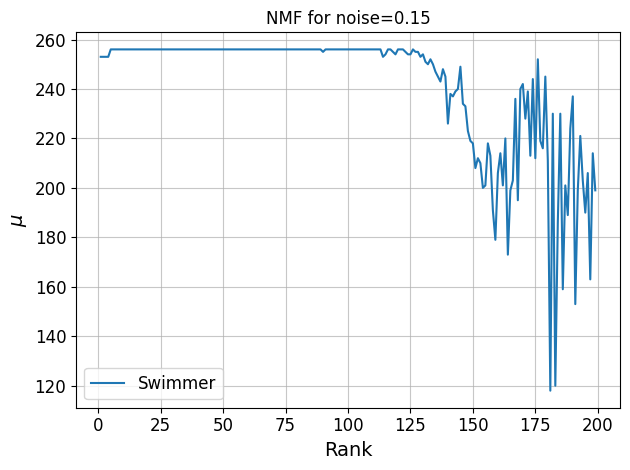

In [135]:
plt.plot(df_nmf_swimmer_15["rank"], df_nmf_swimmer_15["delta_positive_num"], label="Swimmer")
# plt.axhline(1495, color="red")
# plt.ylim(1480, 1510)


plt.grid(True, alpha=0.7)
plt.legend(fontsize=12)
plt.xlabel("Rank", fontsize=14)
plt.ylabel(r"$\mu$", fontsize=14)
plt.title("NMF for noise=0.15")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.savefig("nmf_delta_mean_positiove_num_swimmer_015_v1.pdf")

plt.show()

In [ ]:
df_utk2_15

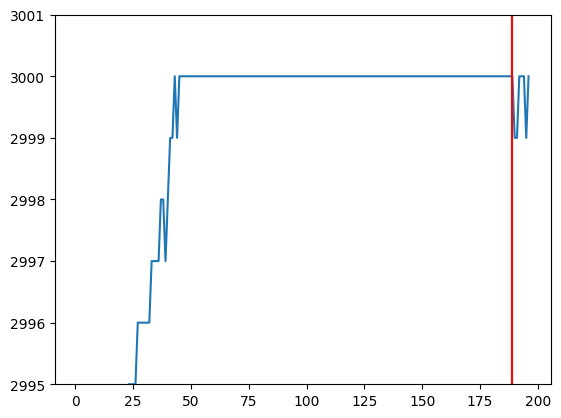

In [70]:
plt.plot(df_utk2_15["rank"], df_utk2_15["delta_positive_num"], label="Utk-2")
plt.ylim(2995, 3001)
plt.axvline(189, color="red")
plt.show()

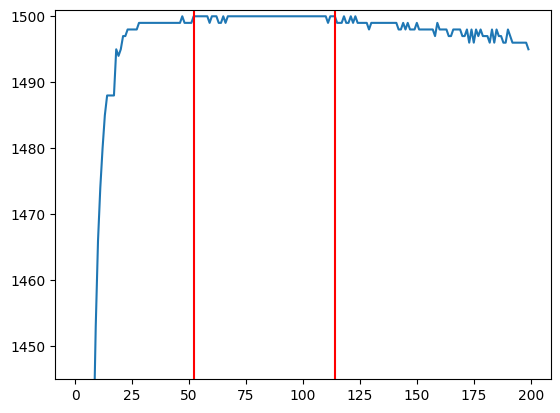

In [78]:
plt.plot(df_utk1_15["rank"], df_utk1_15["delta_positive_num"], label="Utk-2")
plt.ylim(1445, 1501)
plt.axvline(52, color="red")
plt.axvline(114, color="red")
plt.show()

In [83]:
df_pca_swimmer_15 = get_table("PCA_UTK_1500_025_denoise_info")
df_pca_swimmer_15.iloc[:80]

,rank,delta_mean,delta_var,delta_positive_num,denoised_top1,noisy_top1,denoised_top5,noisy_top5,denoised_top10,noisy_top10
0,1,0.023516,0.000455,1402,0.000667,0.447333,0.004000,0.604,0.008667,0.671333
1,2,0.030691,0.000487,1463,0.001333,0.447333,0.006667,0.604,0.013333,0.671333
2,3,0.036760,0.000519,1498,0.001333,0.447333,0.008667,0.604,0.018667,0.671333
3,4,0.039324,0.000510,1499,0.002667,0.447333,0.012000,0.604,0.024667,0.671333
4,5,0.040993,0.000514,1500,0.003333,0.447333,0.014000,0.604,0.026667,0.671333
...,...,...,...,...,...,...,...,...,...,...
75,76,0.044139,0.000301,1500,0.060000,0.447333,0.140000,0.604,0.197333,0.671333
76,77,0.044016,0.000297,1500,0.058667,0.447333,0.138667,0.604,0.197333,0.671333
77,78,0.043944,0.000296,1500,0.062667,0.447333,0.139333,0.604,0.194667,0.671333
78,79,0.043871,0.000294,1500,0.060667,0.447333,0.138000,0.604,0.201333,0.671333


In [147]:
df_nmf_olivetti_25 = get_table("NMF_Olivetti_3000_025_denoise_info")
df_nmf_olivetti_25

,rank,delta_mean,delta_var,delta_positive_num,denoised_top1,noisy_top1,denoised_top5,noisy_top5,denoised_top10,noisy_top10
0,1,0.020396,0.000078,395,0.0025,0.6675,0.0125,0.89,0.0250,0.95
1,2,0.023554,0.000090,400,0.0050,0.6675,0.0200,0.89,0.0325,0.95
2,3,0.025332,0.000095,400,0.0050,0.6675,0.0250,0.89,0.0475,0.95
3,4,0.026407,0.000097,400,0.0025,0.6675,0.0225,0.89,0.0475,0.95
4,5,0.027215,0.000101,400,0.0050,0.6675,0.0275,0.89,0.0775,0.95
...,...,...,...,...,...,...,...,...,...,...
194,195,0.013066,0.000093,400,0.3025,0.6675,0.4725,0.89,0.6250,0.95
195,196,0.012993,0.000091,399,0.2975,0.6675,0.4875,0.89,0.6300,0.95
196,197,0.012894,0.000091,400,0.3000,0.6675,0.4950,0.89,0.6325,0.95
197,198,0.012824,0.000093,399,0.3125,0.6675,0.4875,0.89,0.6400,0.95


In [148]:
get_stats(df_nmf_olivetti_25, 400)

(2, 165, 13, 0.029151660123852934, 198, 0.3125, 1, 199)

In [ ]:
return R1, R2, rank_delta_max, delta_mean_max, rank_acc_max, acc_max, df["rank"].min().item(), df["rank"].max().item()